# 2110573 PATTERN RECOGNITION

## **Homework 02:** MLE and Naive Bayes

- **Author:** Worralop Srichainont
- **Year:** 2025 (Semester 2)

## **Task**: Employee Attrition Prediction

- **Problem**: T4 - T19

# Dependencies

In [261]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# Data Resources

File URL

In [262]:
URL = "https://raw.githubusercontent.com/reisenx/2110573-PATT-RECOG/refs/heads/main/02-Naive-Bayes/Homework/code/hr-employee-attrition-with-null.csv"

Load files by using the first column as an index.

In [263]:
df = pd.read_csv(URL, index_col=0)

Get information of the `DataFrame`

In [264]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1176.000000,1176.000000,1176.00000,1176.000000,1176.0,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,...,1176.000000,1176.0,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,37.134354,798.875850,9.37500,2.920918,1.0,1031.399660,2.733844,65.821429,2.728741,2.072279,...,2.694728,80.0,0.752551,11.295068,2.787415,2.770408,7.067177,4.290816,2.159014,4.096939
std,9.190317,406.957684,8.23049,1.028796,0.0,601.188955,1.092992,20.317323,0.705280,1.105828,...,1.093660,0.0,0.822550,7.783376,1.290507,0.705004,6.127836,3.630901,3.163524,3.537393
min,18.000000,102.000000,1.00000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,457.750000,2.00000,2.000000,1.0,494.750000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,798.500000,7.00000,3.000000,1.0,1027.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1168.250000,15.00000,4.000000,1.0,1562.250000,4.000000,84.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,2.250000,7.000000
max,60.000000,1499.000000,29.00000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


Get sample rows from the `DataFrame`

In [265]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,NaN,NaN,1.0,NaN,Life Sciences,1.0,1.0,...,1.0,80.0,0.0,8.0,0.0,NaN,6.0,NaN,0.0,NaN
1,NaN,No,NaN,279.0,Research & Development,NaN,NaN,Life Sciences,1.0,2.0,...,4.0,NaN,1.0,10.0,NaN,3.0,10.0,NaN,NaN,7.0
2,37.0,Yes,NaN,1373.0,NaN,2.0,2.0,NaN,1.0,4.0,...,NaN,80.0,0.0,7.0,3.0,NaN,NaN,0.0,NaN,0.0
3,NaN,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,NaN,NaN,...,3.0,NaN,NaN,8.0,3.0,NaN,8.0,NaN,3.0,0.0
4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,7.0,...,4.0,80.0,1.0,6.0,NaN,3.0,2.0,2.0,2.0,NaN


# Data Cleaning

## Categorical Columns

For `Attrition` column, convert `yes` and `no` into `1` and `0` respectively.

In [266]:
# Create mappings for converting values.
MAPPINGS = {"Yes": 1, "No": 0}

# Apply mappings.
df["Attrition"] = df["Attrition"].map(MAPPINGS)

Define categorical columns in the `DataFrame`

In [267]:
CATEGORICAL_COLS = [
    "Attrition",
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "Over18",
    "OverTime",
]

Display `DataFrame` on categorical columns before converting.

In [268]:
df[CATEGORICAL_COLS].head()

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,1,Travel_Rarely,NaN,Life Sciences,Female,NaN,Single,Y,Yes
1,0,NaN,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,NaN
2,1,NaN,NaN,NaN,Male,Laboratory Technician,Single,Y,Yes
3,0,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,NaN,Y,Yes
4,0,Travel_Rarely,Research & Development,Medical,Male,NaN,NaN,Y,No


Convert values in categorical columns into numeric values.

**Example**: `BusinessTravel` column
- `Non-Travel` is converted into `0`
- `Travel_Frequently` is converted into `1`
- `Travel_Rarely` is converted into `2`
- Missing value is converted into `-1`

In [269]:
for col_name in CATEGORICAL_COLS:
    df[col_name] = pd.Categorical(df[col_name]).codes

Display `DataFrame` on categorical columns after converting.

In [270]:
df[CATEGORICAL_COLS].head()

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,1,2,-1,1,0,-1,2,0,1
1,0,-1,1,1,1,6,1,0,-1
2,1,-1,-1,-1,1,2,2,0,1
3,0,1,1,1,0,6,-1,0,1
4,0,2,1,3,1,-1,-1,0,0


## Dropping Column

Drop the following columns.

In [271]:
DROP_COLS = ["EmployeeNumber", "EmployeeCount", "StandardHours", "Over18"]

In [272]:
df = df.drop(columns=DROP_COLS)

## Handle Missing Value

For missing values numerical column, we are filling them with mean value. Defaults to disabled.

In [273]:
IS_FILL_MEAN = False

if IS_FILL_MEAN:
    df = df.fillna(df.mean())

# Split Dataset

First, we separate the original `DataFrame` into:
- `X` is the **features** which are all column except the `Attrition` column.
- `y` is the **target** which is only `Attrition` column.

In [274]:
X = df.drop(columns=["Attrition"])
y = df["Attrition"]

Then, split the dataset into train dataset and test dataset by ratio `9:1`:
- **Train dataset** (90% of the dataset) uses for training the model.
- **Test dataset** (10% of the dataset) uses for testing the model.

**Stratification** can ensure that both train datasets and test dataset have the same `0` (no) and `1` (yes) proportions.

To split dataset, use `train_test_split()` function from `sklearn.model_selection`.
- `test_size` is the percentage of test dataset.
- `random_state` is random seed for ensuring the same result when running the code.
- Pass target to `stratify` parameter.

In [275]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=67, stratify=y
)

# Histogram Discretization

To do histogram estimation, do the following steps:
- Divide the entire data space into a finite number of bins.
- Count how many data points are there in each bin
- Normalize using the total number of data points, so that the probability sums to 1.

Since we are grouping a continuous valued feature into a finite number of bins, we can also call this process, **discretization**.

In [276]:
def display_histogram(df, col_name, n_bin=40):
    """A function to display histogram of a dataframe in a specific column.

    Args:
        df (pd.DataFrame): The dataset.
        col_name (str): The specified column name.
        n_bin (int, optional): Amount of histogram bins. Defaults to 40.
    """

    # Remove missing value from a column
    df_col = df[col_name]
    df_col = df_col[~np.isnan(df_col)]

    # Create histogram with specific amount of bins
    hist, bin_edge = np.histogram(df_col, n_bin)

    # Plot a histogram
    plt.figure(figsize=(8, 4))
    plt.fill_between(bin_edge.repeat(2)[1:-1], hist.repeat(2), facecolor="steelblue")
    plt.xlabel("Value")
    plt.ylabel("Counts")
    plt.title(f"The histogram of '{col_name}' column. ({n_bin} bins)")
    plt.show()

    # Output amount of empty bins.
    empty_bins = np.sum(hist == 0)
    print(f"Empty bins in '{col_name}' column is {empty_bins} bins.")

# Problem `T4`

Observe the histogram for `Age`, `MonthlyIncome` and `DistanceFromHome`. How many bins have zero counts? Do you think this is a good discretization? Why?

## Histogram

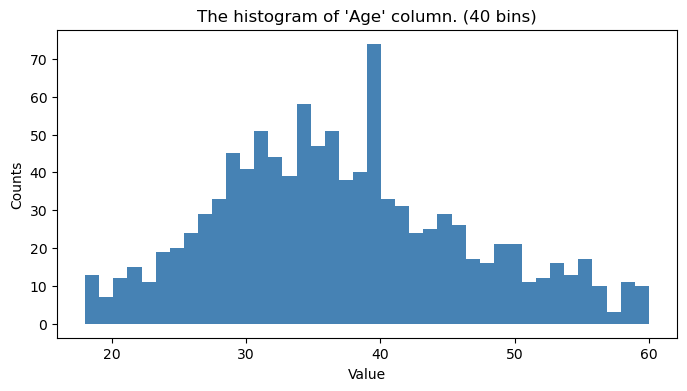

Empty bins in 'Age' column is 0 bins.


In [277]:
display_histogram(X_train, "Age")

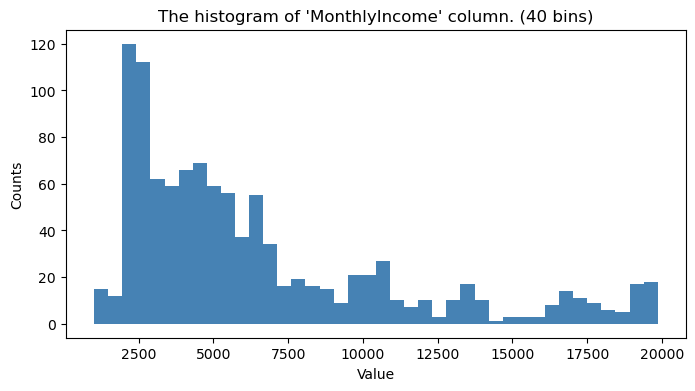

Empty bins in 'MonthlyIncome' column is 0 bins.


In [278]:
display_histogram(X_train, "MonthlyIncome")

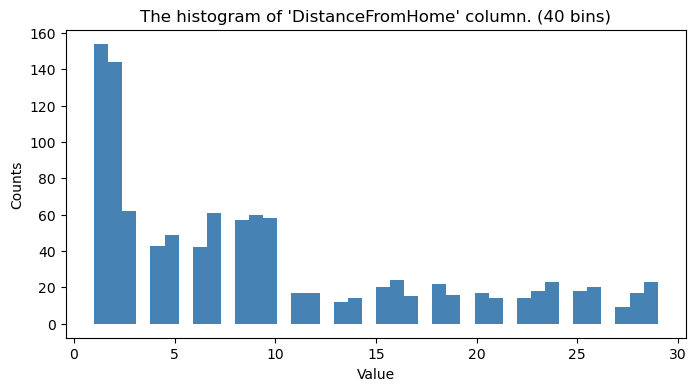

Empty bins in 'DistanceFromHome' column is 11 bins.


In [279]:
display_histogram(X_train, "DistanceFromHome")

## Answer

According to the histogram:
- Empty bins in `Age` column is 0 bins.
- Empty bins in `MonthlyIncome` column is 0 bins.
- Empty bins in `DistanceFromHome` column is 11 bins.

This is not good discretization because
- In `MonthlyIncome` column, it has right-skewed distribution which the right bins have few data and it is likely an outlier. The model would trying to fit with the outlier which causes over-fitting.
- In `DistanceFromHome` column, it has empty bins which breaks the Naive Bayes model, because the probability in empty bin is 0, and the model multiplies probability from every bins.

# Problem `T5`

Can we use a Gaussian to estimate this histogram? Why? What about a
Gaussian Mixture Model (GMM)?

**Requirements**
- First set the number of bins to 10 for `Age`, `MonthlyIncome` and `DistanceFromHome`. Make numbers of bin a parameter as we will change this later.
- Bin each values in the training set into bins using the function `np.digitize`, then count the number in each bins using `np.bincount`.
- Be careful with the maximum and minimum values, your first bin should cover `−inf`, and your final bin should cover `inf`, so that you can handle test data that might be outside of the minimum and maximum values.

## Utility Functions

Create a function to calculate the probabilities of each histogram bins

In [280]:
def get_discretized_probs(df, col_name, n_bin):
    """A function to calculate the probabilities of each histogram bins.

    Args:
        df (pd.DataFrame): The dataset.
        col_name (str): The specified column name.
        n_bin (int): Amount of histogram bins.

    Return
        np.array: The probability in histogram bins.
    """
    # Remove missing value from a column
    df_col = df[col_name]

    # Remove missing value
    df_col = df_col.dropna()

    # Create bin boundaries to cover -inf and inf
    bin_edges = np.linspace(df_col.min(), df_col.max(), n_bin + 1)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    # Find indices of the bin where each data belongs to.
    bin_indices = np.digitize(df_col, bin_edges) - 1

    # Calculate probability of each bins
    bin_counts = np.bincount(bin_indices, minlength=n_bin)
    bin_probs = bin_counts / bin_counts.sum()

    # Return the probability of histogram bins.
    return bin_probs

## Answer

We can use GMM in this problem since some of the feature has normal distribution. Some features may skewed, but it will be better because we mix distribution from multiple features.

# Problem `T6`

Now plot the histogram according to the method described above (with 10, 40, and 100 bins) and show 3 plots each for `Age`, `MonthlyIncome`, and `DistanceFromHome`. Which bin size is most sensible for each features? Why?

## Utility Function

Create a function to display multiple histogram in one figure.

In [281]:
def display_multiple_histogram(df, col_name, n_bin_list=[10, 40, 100]):
    """A function to display multiple histogram of a dataframe in a specific column.

    Args:
        df (pd.DataFrame): The dataset.
        col_name (str): The specified column name.
        n_bins_list: A list of amount of histogram bins. Defaults to [10, 40, 100]
    """

    # Remove missing value from a column
    df_col = df[col_name]
    df_col = df_col[~np.isnan(df_col)]

    # Initialize a list to store amount of empty bins.
    empty_bins = []

    # Create a plotting figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"The histograms of '{col_name}' column")

    # Plot each histogram from by list of bin amount.
    for idx, n_bin in enumerate(n_bin_list):
        # Get probability of each histogram.
        bin_probs = get_discretized_probs(df, col_name, n_bin)

        # Count bin with zero probability.
        empty_bins.append(np.sum(bin_probs == 0))

        # Create histogram labels in horizontal axis.
        display_edges = np.linspace(df_col.min(), df_col.max(), n_bin + 1)
        display_labels = (display_edges[:-1] + display_edges[1:]) / 2

        # Calculate histogram bar width
        bar_width = display_edges[1] - display_edges[0]

        # Plot each histogram
        axes[idx].bar(display_labels, bin_probs, width=bar_width, facecolor="steelblue")
        axes[idx].set_title(f"{n_bin} Bins")
        axes[idx].set_xlabel("Value")
        axes[idx].set_ylabel("Probability")

    # Display histograms
    plt.tight_layout()
    plt.show()

    # Display amount of empty bins
    for idx, n_bin in enumerate(n_bin_list):
        print(f"- Empty bins ({n_bin} bins): {empty_bins[idx]}")

## Display Histograms

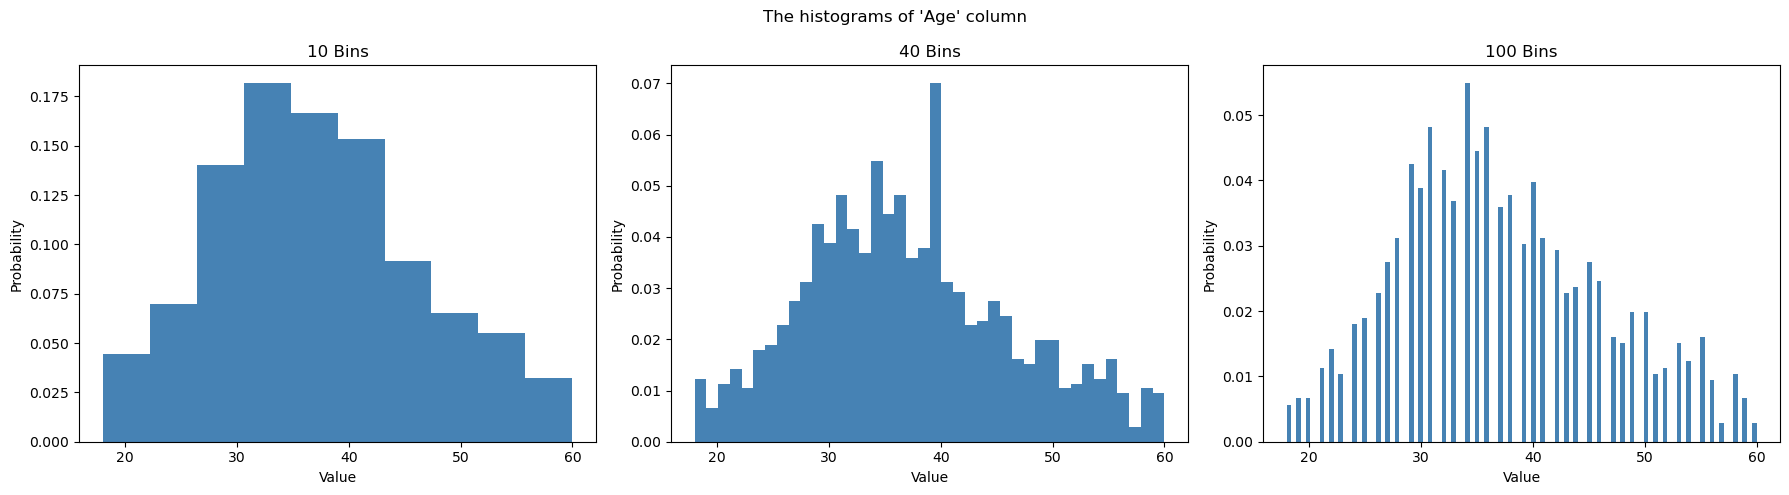

- Empty bins (10 bins): 0
- Empty bins (40 bins): 0
- Empty bins (100 bins): 57


In [282]:
display_multiple_histogram(X_train, "Age")

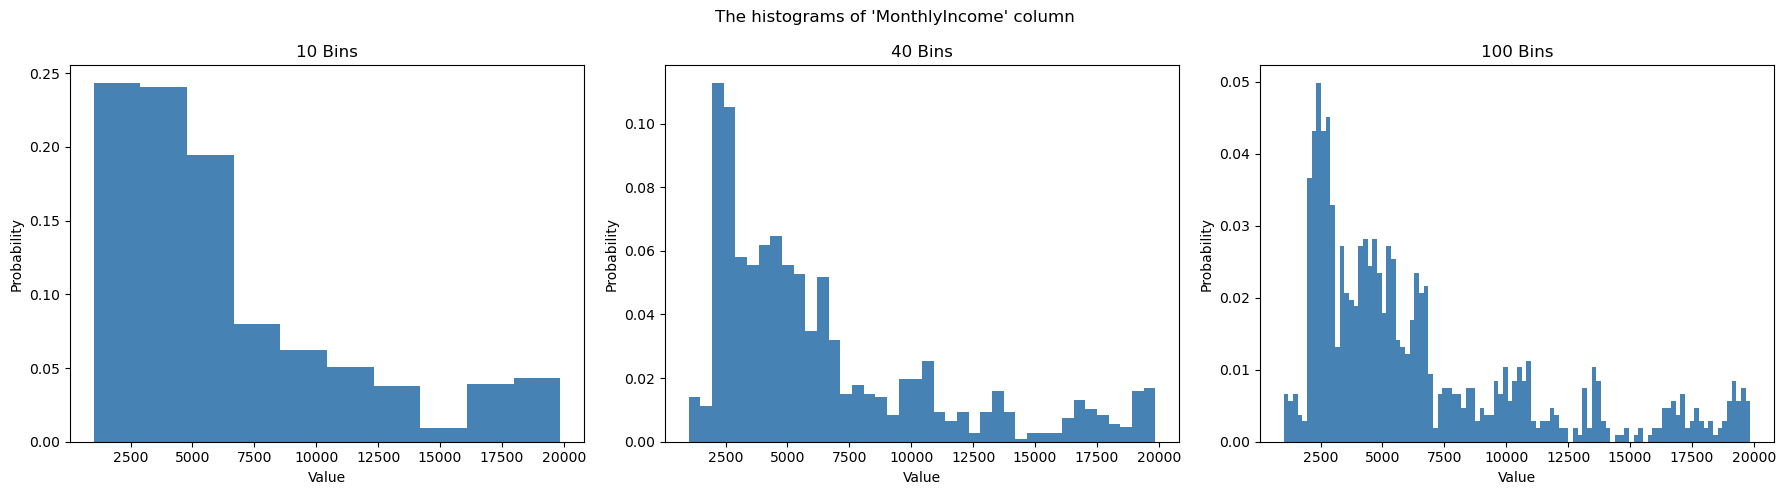

- Empty bins (10 bins): 0
- Empty bins (40 bins): 0
- Empty bins (100 bins): 4


In [283]:
display_multiple_histogram(X_train, "MonthlyIncome")

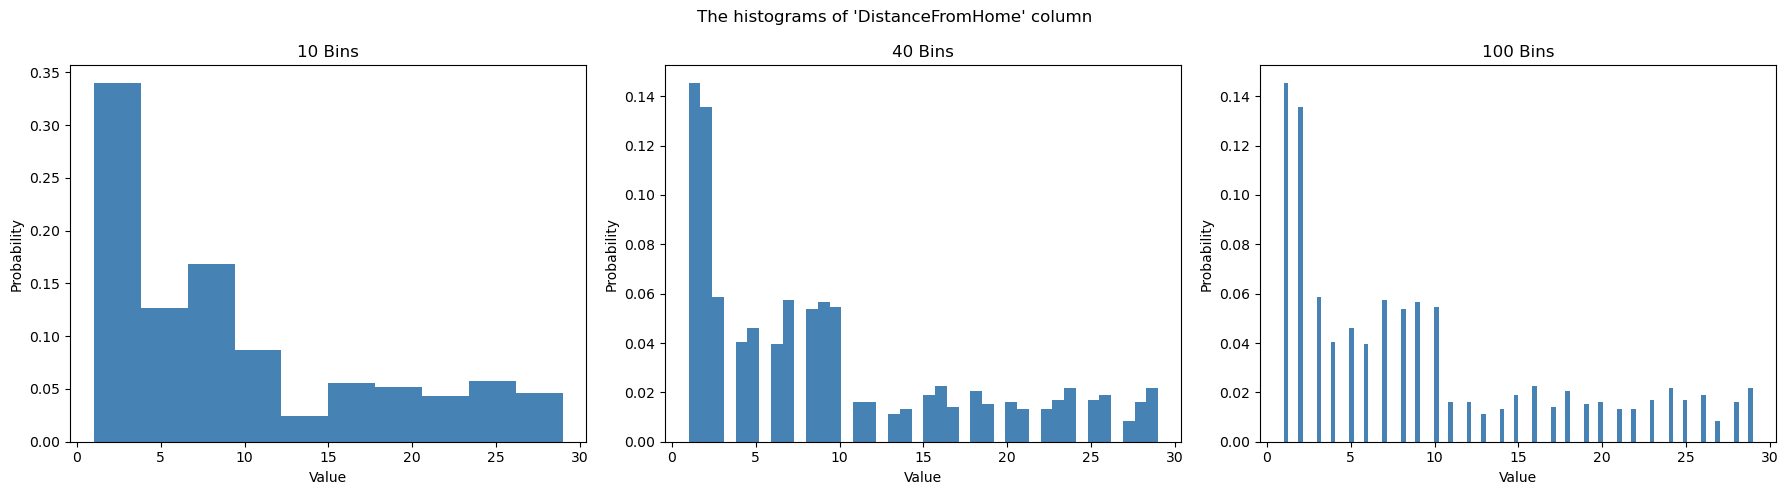

- Empty bins (10 bins): 0
- Empty bins (40 bins): 11
- Empty bins (100 bins): 71


In [284]:
display_multiple_histogram(X_train, "DistanceFromHome")

## Answer

10 bins seems to be the most sensible, because all histogram with 10 bins leaves no empty gap.

# Problem `T7`

For the rest of the features, which one should be discretized in order to be modeled by histograms?

What are the criteria for choosing whether we should discretize a feature or not?

Answer this and discretize those features into 10 bins each. In other words, figure out the bin edge for each feature, then use `digitize()` to convert the features to discrete values.

## Choosing Columns

**Discretization** is to grouping data into a finite number of bins, which means the columns needed to discretize are columns with **continuous numerical values**.

Here are the remaining columns required to discretize.

In [285]:
DISCRETIZE_COLS = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyRate",
    "MonthlyIncome",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
]

Display `DataFrame` before discretization

In [286]:
X_train[DISCRETIZE_COLS]

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyRate,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
266,NaN,NaN,23.0,64.0,14408.0,5582.0,0.0,21.0,NaN,9.0,0.0,NaN,8.0
460,NaN,775.0,29.0,45.0,4267.0,4306.0,NaN,12.0,8.0,0.0,0.0,0.0,0.0
1282,33.0,867.0,8.0,90.0,6076.0,NaN,NaN,19.0,14.0,10.0,8.0,7.0,6.0
1289,38.0,1336.0,2.0,100.0,7129.0,2592.0,5.0,13.0,13.0,11.0,10.0,3.0,NaN
904,NaN,715.0,1.0,76.0,8733.0,18265.0,NaN,12.0,NaN,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,30.0,1339.0,NaN,41.0,NaN,NaN,2.0,12.0,12.0,10.0,9.0,7.0,NaN
675,31.0,154.0,7.0,41.0,11737.0,2329.0,NaN,NaN,13.0,7.0,7.0,5.0,2.0
186,40.0,989.0,4.0,46.0,6499.0,19033.0,1.0,14.0,21.0,NaN,8.0,9.0,9.0
553,40.0,NaN,NaN,NaN,22929.0,2342.0,0.0,20.0,5.0,4.0,2.0,2.0,3.0


## Utility Function

Create a function to discretize value from a specific columns.

In [287]:
def get_discretized_values(df, col_name, n_bin=10):
    """
    A function to return discretize values of the specified column.

    Args:
        df (pd.DataFrame): The dataset.
        col_name (str): The specified column name.
        n_bin (int): Amount of histogram bins.

    Return
        np.ndarray: The discretized values. (-1 for missing values)
    """
    # Remove missing values.
    df_col = df[col_name]
    df_col = df_col.dropna()

    # Create bin boundaries to cover -inf and inf.
    bin_edges = np.linspace(df_col.min(), df_col.max(), n_bin + 1)
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    # Display bin edges of the histogram.
    print(f"Bin edges of '{col_name}' column")
    print(f"{bin_edges}\n")

    # Initialize an array filled with the default value (-1).
    discretized = np.full(df[col_name].size, -1)

    # For non-missing value, find indices of the bin where each data belongs to.
    discretized[df[col_name].notna()] = np.digitize(df_col, bin_edges) - 1

    # Return discretized value.
    return discretized

## Discretize Columns

Apply discretize function to the train dataset.

In [288]:
print("==================== TRAIN DATASET ====================")
for col_name in DISCRETIZE_COLS:
    X_train[col_name] = get_discretized_values(X_train, col_name)

==================== TRAIN DATASET ====================
Bin edges of 'Age' column
[-inf 22.2 26.4 30.6 34.8 39.  43.2 47.4 51.6 55.8  inf]

Bin edges of 'DailyRate' column
[  -inf  241.7  381.4  521.1  660.8  800.5  940.2 1079.9 1219.6 1359.3
    inf]

Bin edges of 'DistanceFromHome' column
[-inf  3.8  6.6  9.4 12.2 15.  17.8 20.6 23.4 26.2  inf]

Bin edges of 'HourlyRate' column
[-inf  37.  44.  51.  58.  65.  72.  79.  86.  93.  inf]

Bin edges of 'MonthlyRate' column
[   -inf  4593.3  7082.6  9571.9 12061.2 14550.5 17039.8 19529.1 22018.4
 24507.7     inf]

Bin edges of 'MonthlyIncome' column
[  -inf  2894.  4779.  6664.  8549. 10434. 12319. 14204. 16089. 17974.
    inf]

Bin edges of 'NumCompaniesWorked' column
[-inf  0.9  1.8  2.7  3.6  4.5  5.4  6.3  7.2  8.1  inf]

Bin edges of 'PercentSalaryHike' column
[-inf 12.4 13.8 15.2 16.6 18.  19.4 20.8 22.2 23.6  inf]

Bin edges of 'TotalWorkingYears' column
[-inf   4.   8.  12.  16.  20.  24.  28.  32.  36.  inf]

Bin edges of 'YearsAt

Apply discretize function to the test dataset.

In [289]:
print("==================== TEST DATASET ====================")
for col_name in DISCRETIZE_COLS:
    X_test[col_name] = get_discretized_values(X_test, col_name)

==================== TEST DATASET ====================
Bin edges of 'Age' column
[-inf 23.1 27.2 31.3 35.4 39.5 43.6 47.7 51.8 55.9  inf]

Bin edges of 'DailyRate' column
[  -inf  256.6  394.2  531.8  669.4  807.   944.6 1082.2 1219.8 1357.4
    inf]

Bin edges of 'DistanceFromHome' column
[-inf  3.8  6.6  9.4 12.2 15.  17.8 20.6 23.4 26.2  inf]

Bin edges of 'HourlyRate' column
[-inf  37.  44.  51.  58.  65.  72.  79.  86.  93.  inf]

Bin edges of 'MonthlyRate' column
[   -inf  4555.3  7016.6  9477.9 11939.2 14400.5 16861.8 19323.1 21784.4
 24245.7     inf]

Bin edges of 'MonthlyIncome' column
[   -inf  3074.1  4887.2  6700.3  8513.4 10326.5 12139.6 13952.7 15765.8
 17578.9     inf]

Bin edges of 'NumCompaniesWorked' column
[-inf  0.9  1.8  2.7  3.6  4.5  5.4  6.3  7.2  8.1  inf]

Bin edges of 'PercentSalaryHike' column
[-inf 12.4 13.8 15.2 16.6 18.  19.4 20.8 22.2 23.6  inf]

Bin edges of 'TotalWorkingYears' column
[-inf  4.5  8.  11.5 15.  18.5 22.  25.5 29.  32.5  inf]

Bin edges o

Display `DataFrame` after discretization.

In [290]:
X_train[DISCRETIZE_COLS]

,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyRate,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
266,-1,-1,7,4,4,2,0,7,-1,2,0,-1,4
460,-1,4,9,2,0,1,-1,0,2,0,0,0,0
1282,3,5,2,8,1,-1,-1,5,3,2,4,4,3
1289,4,8,0,9,2,0,5,1,3,2,5,2,-1
904,-1,4,0,6,2,9,-1,0,-1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
167,2,8,-1,1,-1,-1,2,0,3,2,5,4,-1
675,3,0,2,1,3,0,-1,-1,3,1,3,3,1
186,5,6,1,2,1,9,1,2,5,-1,4,6,5
553,5,-1,-1,-1,8,0,0,6,1,1,1,1,1


# Problem `T8`

**The MLE for the likelihood distribution of discretized histograms**

We would like to build a Naive Bayes classifier which compares the posterior $p(leave|x_i)$ against $p(stay|x_i)$.

However, figuring out $p(class|x_i)$ is often hard (not true for this case).

Thus, we turn to the likelihood $p(x_i|class)$, which can be derived from the discretized histograms.

What kind of distribution should we use to model histograms? (Answer a distribution name) 

What is the MLE for this likelihood distribution? (Describe how to do the MLE).

Plot the likelihood distributions of `MonthlyIncome`, `JobRole`, `HourlyRate`, and `MaritalStatus` for different `Attrition` values.

**Hint**: in class we talk about how a fair coin can be modeled using the Bernoulli distribution. A histogram is very similar to a dice in the sense that the outcome
is a set of possibilities.

## Choosing Distribution

Choose **Categorical Distribution** to model histograms.

**Categorical Distribution** is a probability distribution that describes the result of a random event that can take on one of $K$ possible outcomes.

Given probability $\mathbf{p} = \{p_1, p_2, \dots, p_k\}$, which it needs to meet to constraints.

- $0 \le p_{k} \le 1$
- $\sum_{k = 1}^{K} (p_k) = 1$

## Maximum Likelihood Distribution (MLE)

Given $n_k$ is the data count in the category $k$, and $N$ is the total data count.

The Maximum Likelihood Distribution (MLE) for $p_k$ which is the probability in category $k$ in categorical distribution is:

$${\hat{p}}_{k} = \frac{n_k}{N} $$


## Utility Function

Create a function that can plot histogram of the specified separated by `Attribution` column.

In [291]:
def display_histogram_by_attribution(features_df, target_df, col_name):
    """
    A function to display histogram separated by the attribution.

    Args:
        features_df (pd.DataFrame): The features part of the dataset.
        target_df (pd.Series): The target part of the dataset.
        col_name (str): The specified column name.
    """
    # Split the feature data by target class
    features_stay = features_df.loc[target_df == 0, col_name]
    features_leave = features_df.loc[target_df == 1, col_name]

    # Calculate the probability (MLE)
    # Set normalize=True to calculate ratio with the total count
    probs_stay = features_stay.value_counts(normalize=True).sort_index()
    probs_leave = features_leave.value_counts(normalize=True).sort_index()

    # Get all unique bins present in either group
    all_bins = sorted(list(set(probs_stay.index) | set(probs_leave.index)))

    # Reindex to fill missing bins with 0 probability
    probs_stay = probs_stay.reindex(all_bins, fill_value=0)
    probs_leave = probs_leave.reindex(all_bins, fill_value=0)

    # Histogram plotting
    x = np.arange(len(all_bins))
    width = 0.35

    # Create subplots
    _, ax = plt.subplots(figsize=(10, 7))

    # Plot Stay (0) bars shifted left
    ax.bar(x - (width / 2), probs_stay, width, label="Stay (0)", color="steelblue")

    # Plot Leave (1) bars shifted right
    ax.bar(x + (width / 2), probs_leave, width, label="Leave (1)", color="salmon")

    # Set histogram title and axis names
    ax.set_xlabel("Bin Index")
    ax.set_ylabel("Probability (MLE)")
    ax.set_title(f"The Likelihood P(x|Class) for '{col_name}' column")

    # Set labels in the horizontal axis
    ax.set_xticks(x)
    ax.set_xticklabels(all_bins)
    ax.legend()

    # Display the histogram
    plt.tight_layout()
    plt.show()

## Plot Likelihood Distribution

Plot likelihood distribution of the following columns.

In [292]:
TARGET_COLS = ["MonthlyIncome", "JobRole", "HourlyRate", "MaritalStatus"]

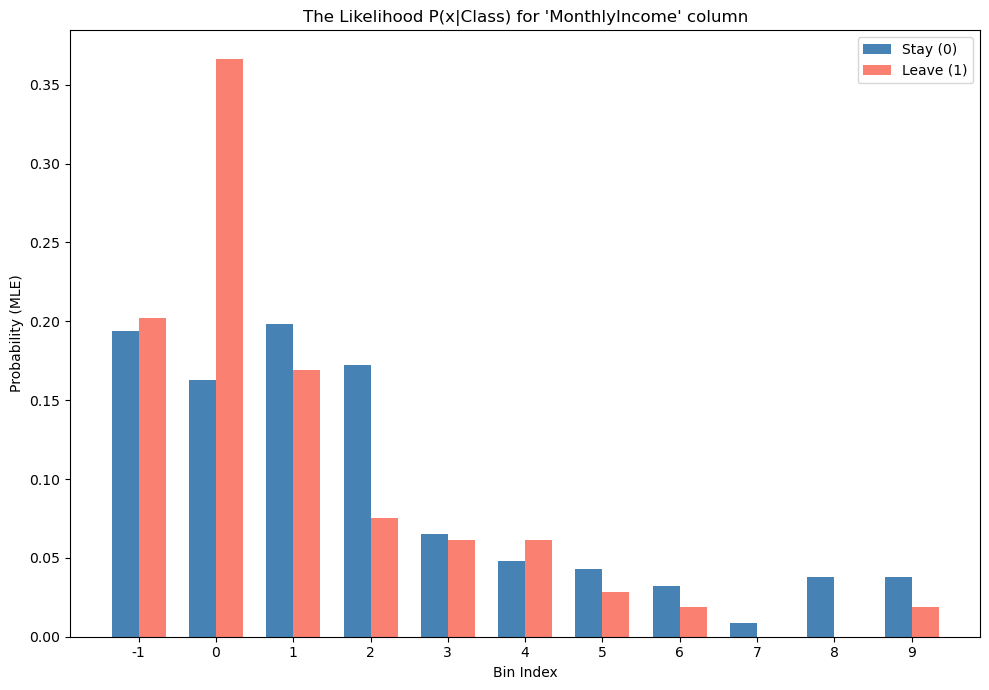

In [293]:
display_histogram_by_attribution(X_train, y_train, TARGET_COLS[0])

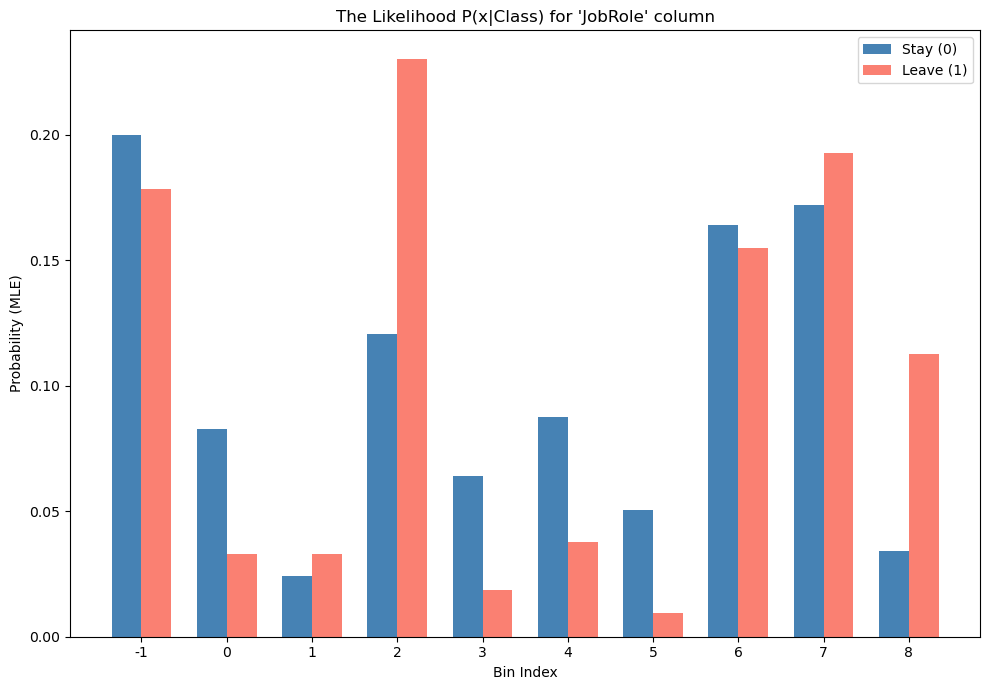

In [294]:
display_histogram_by_attribution(X_train, y_train, TARGET_COLS[1])

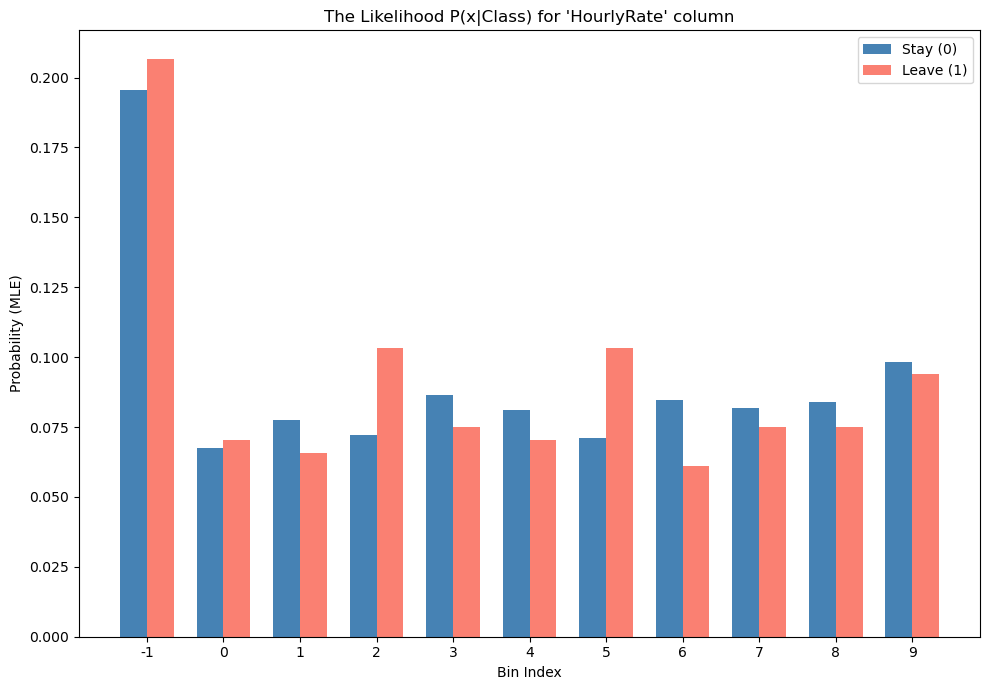

In [295]:
display_histogram_by_attribution(X_train, y_train, TARGET_COLS[2])

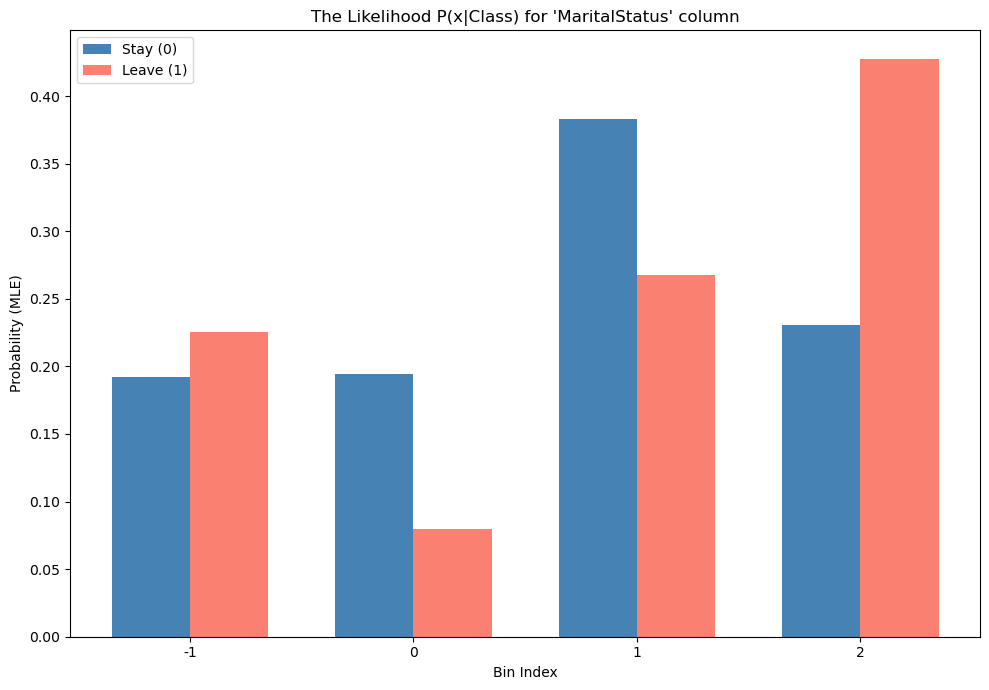

In [296]:
display_histogram_by_attribution(X_train, y_train, TARGET_COLS[3])

# Problem `T9`

What is the prior distribution of the two classes?

To calculate the prior probability, simply calculate by:

\begin{align*}
    P(\text{leave}) &= \frac{n_{\text{leave}}}{N} \\[0.5em]
    P(\text{stay}) &= \frac{n_{\text{stay}}}{N}
\end{align*}

In [297]:
# Calculate prior probability
p_stay = y_train.sum() / y_train.size
p_leave = 1.0 - p_stay

# Display prior probability
print(f"Prior Probability of 'stay' class is {p_stay:.4f}")
print(f"Prior Probability of 'leave' class is {p_leave:.4f}")

Prior Probability of 'stay' class is 0.1610
Prior Probability of 'leave' class is 0.8390


# Problem `T10`

If we use the current Naive Bayes with our current Maximum Likelihood Estimates, we will find that some $P(x_i|attrition)$ will be zero and will result in the entire product term to be zero.

Propose a method to fix this problem.

## Laplace Smoothing

To deal with zero probability, we need to add the pseudo-count when calculating the probability.

$${p}_{\text{class}} = \frac{{\text{Count}}_{\text{class}} + \alpha}{{\text{Count}}_{\text{total}} + (\alpha \cdot K)}$$

Given that:
- ${p}_{\text{class}}$ is the probability of the class.
- ${\text{Count}}_{\text{class}}$ is the data count in the class.
- ${\text{Count}}_{\text{total}}$ is the total data count.
- $\alpha$ is the smoothing parameter (pseudo-count).
- $K$ is the category classes.

We usually set pseudo-count $\alpha = 1$, so the formula would be:
$${p}_{\text{class}} = \frac{{\text{Count}}_{\text{class}} + 1}{{\text{Count}}_{\text{total}} + K}$$

# Problem `T11`

Implement your Naive Bayes classifier. Use the learned distributions to classify the test set. Don’t forget to allow your classifier to handle missing values in the test set. Report the overall Accuracy. Then, report the Precision, Recall, and F1-score for detecting attrition. 

## Model Implementation

Create a simple Bayes Classifier from scratch.

In [ ]:
class SimpleBayesClassifier:
    def __init__(self, n_pos, n_neg):
        """
        Initializes the SimpleBayesClassifier with prior probabilities.

        Parameters:
            n_pos (int): The number of positive samples.
            n_neg (int): The number of negative samples.

        Returns:
            None: This method does not return anything as it is a constructor.
        """

        # Initialize amount of positive and negative class.
        self.n_pos = n_pos
        self.n_neg = n_neg

        # Calculate the prior probability for positive and negative class.
        self.prior_pos = n_pos / (n_pos + n_neg)
        self.prior_neg = n_neg / (n_pos + n_neg)

        # Additional attributes to prevent dividing by zero.
        self.epsilon = 1e-9

    def fit_params(self, x, y, n_bins=10):
        """
        Computes histogram-based parameters for each feature in the dataset.

        Parameters:
            x (np.ndarray): The feature matrix, where rows are samples and columns are features.
            y (np.ndarray): The target array, where each element corresponds to the label of a sample.
            n_bins (int): Number of bins to use for histogram calculation.

        Returns:
            (stay_params, leave_params): A tuple containing two lists of tuples,
                one for 'stay' parameters and one for 'leave' parameters.
                Each tuple in the list contains the bins and edges of the histogram for a feature.
        """
        # Initialize object attributes to store parameters.
        self.stay_params = [(None, None) for _ in range(x.shape[1])]
        self.leave_params = [(None, None) for _ in range(x.shape[1])]

        # Separate features by positive and negative class.
        x_positive = x[y == 1]
        x_negative = x[y == 0]

        # Iterate each features
        for idx in range(x.shape[1]):
            # Get the current feature.
            feature_all = x[:, idx]
            feature_positive = x_positive[:, idx]
            feature_negative = x_negative[:, idx]

            # Remove missing values
            feature_all = feature_all[~np.isnan(feature_all)]
            feature_positive = feature_positive[~np.isnan(feature_positive)]
            feature_negative = feature_negative[~np.isnan(feature_negative)]

            # Calculate histogram edges from all data in the current features.
            _, bin_edges = np.histogram(feature_all, bins=n_bins)

            # Apply bin edges to positive and negative class to get count values.
            counts_positive, _ = np.histogram(feature_positive, bins=bin_edges)
            counts_negative, _ = np.histogram(feature_negative, bins=bin_edges)

            # Add pseudo counts
            counts_positive += 1
            counts_negative += 1

            # Calculate probability density of the histogram
            bin_widths = np.diff(bin_edges)
            probs_positive = counts_positive / (
                (counts_positive.sum() * bin_widths) + self.epsilon
            )
            probs_negative = counts_negative / (
                (counts_negative.sum() * bin_widths) + self.epsilon
            )

            # Store parameters
            self.stay_params[idx] = (probs_positive, bin_edges)
            self.leave_params[idx] = (probs_negative, bin_edges)

        # Returns histogram parameters.
        return self.stay_params, self.leave_params

    def predict(self, x, thresh=0.0):
        """
        Predicts the class labels for the given samples using the non-parametric model.

        Parameters:
            x (np.ndarray): The feature matrix for which predictions are to be made.
            thresh (float): The threshold for log probability to decide between classes.

        Returns:
            result (list): A list of predicted class labels (0 or 1) for each sample in the feature matrix.
        """
        # Get amount of samples and features of the feature matrix
        n_samples, n_features = x.shape

        # Initialize log-probability array with logarithm of prior probability.
        log_probs_positive = np.full(n_samples, np.log(self.prior_pos))
        log_probs_negative = np.full(n_samples, np.log(self.prior_neg))

        # Iterate each feature in features matrix
        for idx in range(n_features):
            # Extract only the current features.
            feature_col = x[:, idx]

            # Create a mask to ignore missing value.
            is_valid = ~np.isnan(feature_col)

            # Remove missing value
            feature_col = feature_col[is_valid]

            # Skip the column, if the current feature has all missing values.
            if feature_col.size == 0:
                continue

            # Get probability and edges of positive and negative class.
            probs_positive, bin_edges_positive = self.stay_params[idx]
            probs_negative, bin_edges_negative = self.leave_params[idx]

            # Calculate bin indices of positive and negative class.
            bin_indices_positive = np.searchsorted(bin_edges_positive, feature_col) - 1
            bin_indices_negative = np.searchsorted(bin_edges_negative, feature_col) - 1

            # Ensure that the indices is not out of range
            bin_indices_positive = np.clip(
                bin_indices_positive, 0, probs_positive.size - 1
            )
            bin_indices_negative = np.clip(
                bin_indices_negative, 0, probs_negative.size - 1
            )

            # Update log-probability only for non-missing value rows.
            log_probs_positive[is_valid] += np.log(
                probs_positive[bin_indices_positive] + self.epsilon
            )
            log_probs_negative[is_valid] += np.log(
                probs_negative[bin_indices_negative] + self.epsilon
            )

        # Predict classification by threshold
        predictions = np.where((log_probs_positive - log_probs_negative) > thresh, 1, 0)

        # Return predictions as a list
        return predictions.tolist()

    def fit_gaussian_params(self, x, y):
        """
        Computes mean and standard deviation for each feature in the dataset.

        Parameters:
            x (np.ndarray): The feature matrix, where rows are samples and columns are features.
            y (np.ndarray): The target array, where each element corresponds to the label of a sample.

        Returns:
            (gaussian_stay_params, gaussian_leave_params): A tuple containing two lists of tuples,
                one for 'stay' parameters and one for 'leave' parameters.
                Each tuple in the list contains the mean and standard deviation for a feature.
        """
        # Initialize object attributes to store gaussian parameters.
        self.gaussian_stay_params = [(0, 0) for _ in range(x.shape[1])]
        self.gaussian_leave_params = [(0, 0) for _ in range(x.shape[1])]

        # Separate features by positive and negative class.
        x_positive = x[y == 1]
        x_negative = x[y == 0]

        # Iterate each features
        for idx in range(x.shape[1]):
            # Get the current feature.
            feature_all = x[:, idx]
            feature_positive = x_positive[:, idx]
            feature_negative = x_negative[:, idx]

            # Remove missing values
            feature_all = feature_all[~np.isnan(feature_all)]
            feature_positive = feature_positive[~np.isnan(feature_positive)]
            feature_negative = feature_negative[~np.isnan(feature_negative)]

            # Initialize mean and standard deviation variables
            mean_positive = 0.0
            mean_negative = 0.0
            std_positive = 1.0
            std_negative = 1.0

            # Calculate mean and standard deviation of positive class.
            if feature_positive.size > 0:
                mean_positive = np.mean(feature_positive)
                std_positive = np.std(feature_positive) + self.epsilon

            # Calculate mean and standard deviation of negative class.
            if feature_negative.size > 0:
                mean_negative = np.mean(feature_negative)
                std_negative = np.std(feature_negative) + self.epsilon

            # Store mean and standard deviation values
            self.gaussian_stay_params[idx] = (mean_positive, std_positive)
            self.gaussian_leave_params[idx] = (mean_negative, std_negative)

        # Returns gaussian parameters.
        return self.gaussian_stay_params, self.gaussian_leave_params

    def gaussian_predict(self, x, thresh=0):
        """
        Predicts the class labels for the given samples using the parametric model.

        Parameters:
            x (np.ndarray): The feature matrix for which predictions are to be made.
            thresh (float): The threshold for log probability to decide between classes.

        Returns:
            result (list): A list of predicted class labels (0 or 1) for each sample in the feature matrix.
        """
        # Get amount of samples and features of the feature matrix
        n_samples, n_features = x.shape

        # Initialize log-probability array with logarithm of prior probability.
        log_probs_positive = np.full(n_samples, np.log(self.prior_pos))
        log_probs_negative = np.full(n_samples, np.log(self.prior_neg))

        # Iterate each feature in features matrix
        for idx in range(n_features):
            # Extract only the current features.
            feature_col = x[:, idx]

            # Create a mask to ignore missing value.
            is_valid = ~np.isnan(feature_col)

            # Remove missing value
            feature_col = feature_col[is_valid]

            # Skip the column, if the current feature has all missing values.
            if feature_col.size == 0:
                continue

            # Get mean and standard deviation value of positive class and negative class
            mean_positive, std_positive = self.gaussian_stay_params[idx]
            mean_negative, std_negative = self.gaussian_leave_params[idx]

            # Calculate logarithm of probability density
            # and update log-probability only for non-missing value rows.
            log_probs_positive[is_valid] += stats.norm.logpdf(
                feature_col, loc=mean_positive, scale=std_positive + self.epsilon
            )
            log_probs_negative[is_valid] += stats.norm.logpdf(
                feature_col, loc=mean_negative, scale=std_negative + self.epsilon
            )

        # Predict classification by threshold
        predictions = np.where((log_probs_positive - log_probs_negative) > thresh, 1, 0)

        # Return predictions as a list
        return predictions.tolist()

    def predict_scores(self, x):
        """
        Returns the log-odds ratio (score) for ROC plotting.
        Score > 0 means 'Stay', Score < 0 means 'Leave'.
        """
        n_samples, n_features = x.shape

        # Initialize with Priors
        log_probs_positive = np.full(n_samples, np.log(self.prior_pos))
        log_probs_negative = np.full(n_samples, np.log(self.prior_neg))

        for idx in range(n_features):
            feature_col = x[:, idx]
            is_valid = ~np.isnan(feature_col)
            feature_col = feature_col[is_valid]

            if feature_col.size == 0:
                continue

            probs_positive, bin_edges_positive = self.stay_params[idx]
            probs_negative, bin_edges_negative = self.leave_params[idx]

            bin_indices_positive = np.searchsorted(bin_edges_positive, feature_col) - 1
            bin_indices_negative = np.searchsorted(bin_edges_negative, feature_col) - 1

            bin_indices_positive = np.clip(
                bin_indices_positive, 0, probs_positive.size - 1
            )
            bin_indices_negative = np.clip(
                bin_indices_negative, 0, probs_negative.size - 1
            )

            log_probs_positive[is_valid] += np.log(
                probs_positive[bin_indices_positive] + self.epsilon
            )
            log_probs_negative[is_valid] += np.log(
                probs_negative[bin_indices_negative] + self.epsilon
            )

        return log_probs_positive - log_probs_negative

## Model Testing

Create a class for Naive Bayes model testing.

In [299]:
class SimpleBayesClassifierTest:
    @staticmethod
    def check_prior():
        """
        This function designed to test the implementation of the prior probability calculation in a Naive Bayes classifier.
        Specifically, it checks if the classifier correctly computes the prior probabilities for the
        negative and positive classes based on given input counts.
        """
        assert (
            SimpleBayesClassifier(5, 5).prior_pos,
            SimpleBayesClassifier(5, 5).prior_neg,
        ) == (5 / 10, 5 / 10)
        assert (
            SimpleBayesClassifier(3, 5).prior_pos,
            SimpleBayesClassifier(3, 5).prior_neg,
        ) == (3 / 8, 5 / 8)
        assert (
            SimpleBayesClassifier(0, 1).prior_pos,
            SimpleBayesClassifier(0, 1).prior_neg,
        ) == (0 / 1, 1 / 1)
        assert (
            SimpleBayesClassifier(1, 0).prior_pos,
            SimpleBayesClassifier(1, 0).prior_neg,
        ) == (1 / 1, 0 / 1)

    @staticmethod
    def check_fit_params():
        """
        This function is designed to test the fit_params method of a SimpleBayesClassifier.
        This method is presumably responsible for computing parameters for a Naive Bayes classifier
        based on the provided training data. The parameters in this context is bins and edges from each histogram.
        """
        T = SimpleBayesClassifier(2, 2)
        X_TRAIN_CASE_1 = np.array(
            [[0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 6]]
        )
        Y_TRAIN_CASE_1 = np.array([0, 1, 0, 1])
        STAY_PARAMS_1, LEAVE_PARAMS_1 = T.fit_params(X_TRAIN_CASE_1, Y_TRAIN_CASE_1)

        print("STAY PARAMETERS")
        for f_idx in range(len(STAY_PARAMS_1)):
            print(f"Feature : {f_idx}")
            print(f"BINS : {STAY_PARAMS_1[f_idx][0]}")
            print(f"EDGES : {STAY_PARAMS_1[f_idx][1]}")

        print("\nLEAVE PARAMETERS")
        for f_idx in range(len(STAY_PARAMS_1)):
            print(f"Feature : {f_idx}")
            print(f"BINS : {LEAVE_PARAMS_1[f_idx][0]}")
            print(f"EDGES : {LEAVE_PARAMS_1[f_idx][1]}")

    @staticmethod
    def check_fit_gaussian_params():
        """
        This function is designed to test the fit_gaussian_params method of a SimpleBayesClassifier.
        This method is presumably responsible for computing parameters for a Naive Bayes classifier
        based on the provided training data. The parameters in this context is mean and STD.
        """

        T = SimpleBayesClassifier(2, 2)
        X_TRAIN_CASE_1 = np.array(
            [[0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 6]]
        )
        Y_TRAIN_CASE_1 = np.array([0, 1, 0, 1])
        STAY_PARAMS_1, LEAVE_PARAMS_1 = T.fit_gaussian_params(
            X_TRAIN_CASE_1, Y_TRAIN_CASE_1
        )

        print("STAY PARAMETERS")
        for f_idx in range(len(STAY_PARAMS_1)):
            print(f"Feature : {f_idx}")
            print(f"Mean : {STAY_PARAMS_1[f_idx][0]}")
            print(f"STD. : {STAY_PARAMS_1[f_idx][1]}")

        print("\nLEAVE PARAMETERS")
        for f_idx in range(len(STAY_PARAMS_1)):
            print(f"Feature : {f_idx}")
            print(f"Mean : {LEAVE_PARAMS_1[f_idx][0]}")
            print(f"STD. : {LEAVE_PARAMS_1[f_idx][1]}")

Call `check_prior()` to test if the Naive Bayes model calculates prior probability correctly.

In [300]:
SimpleBayesClassifierTest.check_prior()

Call `check_fit_param()` to see returned value from `fit_param()` method in the Naive Bayes model.

In [301]:
SimpleBayesClassifierTest.check_fit_params()

STAY PARAMETERS
Feature : 0
BINS : [0.27777778 0.27777778 0.27777778 0.55555556 0.27777778 0.27777778
 0.27777778 0.27777778 0.27777778 0.55555556]
EDGES : [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
Feature : 1
BINS : [0.27777778 0.27777778 0.27777778 0.55555556 0.27777778 0.27777778
 0.27777778 0.27777778 0.27777778 0.55555556]
EDGES : [1.  1.3 1.6 1.9 2.2 2.5 2.8 3.1 3.4 3.7 4. ]
Feature : 2
BINS : [0.27777778 0.27777778 0.27777778 0.55555556 0.27777778 0.27777778
 0.27777778 0.27777778 0.27777778 0.55555556]
EDGES : [2.  2.3 2.6 2.9 3.2 3.5 3.8 4.1 4.4 4.7 5. ]
Feature : 3
BINS : [0.27777778 0.27777778 0.27777778 0.55555556 0.27777778 0.27777778
 0.27777778 0.27777778 0.27777778 0.55555556]
EDGES : [3.  3.3 3.6 3.9 4.2 4.5 4.8 5.1 5.4 5.7 6. ]

LEAVE PARAMETERS
Feature : 0
BINS : [0.55555556 0.27777778 0.27777778 0.27777778 0.27777778 0.27777778
 0.55555556 0.27777778 0.27777778 0.27777778]
EDGES : [0.  0.3 0.6 0.9 1.2 1.5 1.8 2.1 2.4 2.7 3. ]
Feature : 1
BINS : [0.55555556 0.277

## Model Predictions

First, we need to convert test and train dataset from `pd.DataFrame` or `pd.Series` into `np.ndarray` type.

In [302]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()
X_test = X_test.to_numpy()
y_test = y_test.to_numpy()

Then, count amount of positive and negative class in the train dataset.

In [303]:
n_positive = np.sum(y_train == 1)
n_negative = np.sum(y_train == 0)

print(f"- There are {n_positive} positives in the train dataset.")
print(f"- There are {n_negative} negatives in the train dataset.")

- There are 213 positives in the train dataset.
- There are 1110 negatives in the train dataset.


Initialize a Naive Bayes model

In [304]:
model = SimpleBayesClassifier(n_positive, n_negative)

Train a Naive Bayes model using test dataset.

In [305]:
model.fit_params(X_train, y_train)

([(array([0.20627803, 0.10313901, 0.10762332, 0.13004484, 0.16143498,
          0.07174888, 0.06278027, 0.05381166, 0.03587444, 0.06726457]),
   array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.])),
  (array([0.62780269, 0.01494768, 0.01494768, 0.14947683, 0.01494768,
          0.01494768, 0.7922272 , 0.01494768, 0.01494768, 1.67414051]),
   array([-1. , -0.7, -0.4, -0.1,  0.2,  0.5,  0.8,  1.1,  1.4,  1.7,  2. ])),
  (array([0.24215247, 0.07174888, 0.11210762, 0.07174888, 0.10313901,
          0.06278027, 0.06726457, 0.05381166, 0.08071749, 0.13452915]),
   array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.])),
  (array([0.73243647, 0.01494768, 0.01494768, 0.13452915, 0.01494768,
          0.01494768, 1.40508221, 0.01494768, 0.01494768, 0.9715994 ]),
   array([-1. , -0.7, -0.4, -0.1,  0.2,  0.5,  0.8,  1.1,  1.4,  1.7,  2. ])),
  (array([0.15695067, 0.21973094, 0.08071749, 0.12107623, 0.08071749,
          0.03587444, 0.07174888, 0.04484305, 0.05381166, 0.13452915

Use a model to predict the test dataset.

In [306]:
y_pred = model.predict(X_test)

## Model Evaluation

Create a utility class for evaluating the classifier model.

In [307]:
class ClassificationEvaluator:
    @staticmethod
    def get_confusion_matrix(truths, predictions):
        """
        Calculate counts in confusion matrix.

        Args:
            truths (np.ndarray): Ground truths.
            predictions (np.ndarray): Model predictions.

        Returns:
            tuple(int, int, int, int): True positive, False positive,
                True negative and False negative.
        """
        # Calculate counts in confusion matrix.
        true_pos = np.sum((predictions == 1) & (truths == 1))
        false_pos = np.sum((predictions == 1) & (truths == 0))
        true_neg = np.sum((predictions == 0) & (truths == 0))
        false_neg = np.sum((predictions == 0) & (truths == 1))

        # Return values
        return (true_pos, false_pos, true_neg, false_neg)

    @staticmethod
    def get_rates(truths, predictions):
        """
        Calculate evaluation rates of model predictions.

        Args:
            truths (np.ndarray): Ground truths.
            predictions (np.ndarray): Model predictions.

        Returns:
            tuple(float, float, float, float): Accuracy, Precision,
                Recall and False Positive Rate.
        """
        # Get confusion matrix.
        true_pos, false_pos, true_neg, false_neg = (
            ClassificationEvaluator.get_confusion_matrix(truths, predictions)
        )

        # Calculate variables used in rate calculation.
        total = truths.size
        actual_false = false_pos + true_neg
        actual_true = true_pos + false_neg
        predicted_true = true_pos + false_pos
        correctly_predicted = true_pos + true_neg

        # Initialize default value of rates.
        accuracy = 0.0
        precision = 0.0
        recall = 0.0
        false_positive_rate = 0.0

        # Rate calculation with divide by zero handling.
        if total > 0:
            accuracy = correctly_predicted / total
        if predicted_true > 0:
            precision = true_pos / predicted_true
        if actual_true > 0:
            recall = true_pos / actual_true
        if actual_false > 0:
            false_positive_rate = false_pos / actual_false

        # Return rate values
        return (accuracy, precision, recall, false_positive_rate)

    @staticmethod
    def get_f1_score(truths, predictions):
        """
        Calculate F1 score of model predictions.

        Args:
            truths (np.ndarray): Ground truths.
            predictions (np.ndarray): Model predictions.

        Returns:
            float: F1 score
        """
        # Get evaluation rates.
        _, precision, recall, _ = ClassificationEvaluator.get_rates(truths, predictions)

        # Initialize default value of F1 score.
        f1_score = 0.0

        # Calculate F1 score with divide by zero handling.
        if precision + recall > 0:
            f1_score = (2 * precision * recall) / (precision + recall)

        # Return F1 score
        return f1_score

    @staticmethod
    def display_evaluation_report(truths, predictions):
        """
        Display model evaluation report with multiple metrics.

        Args:
            truths (np.ndarray): Ground truths.
            predictions (np.ndarray): Model predictions.
        """
        # Get confusion matrix.
        true_pos, false_pos, true_neg, false_neg = (
            ClassificationEvaluator.get_confusion_matrix(truths, predictions)
        )

        # Get evaluation rates.
        accuracy, precision, recall, false_positive_rate = (
            ClassificationEvaluator.get_rates(truths, predictions)
        )

        # Get F1 score.
        f1_score = ClassificationEvaluator.get_f1_score(truths, predictions)

        # Display confusion matrix
        print("=============== EVALUATION REPORT ================")
        print("Confusion Matrix:")
        print(f"  [[TP = {true_pos},\tFN = {false_neg}]")
        print(f"   [FP = {false_pos},\tTN = {true_neg}]]")
        print("--------------------------------------------------")
        print(f"Accuracy:            {accuracy:.4f}")
        print(f"Precision:           {precision:.4f}")
        print(f"Recall:              {recall:.4f}")
        print(f"False Positive Rate: {false_positive_rate:.4f}")
        print("--------------------------------------------------")
        print(f"F1 Score:            {f1_score:.4f}")
        print("==================================================")

Display model evaluation report.

In [308]:
print("****** Naive Bayes Model (Histogram Method) ******")
ClassificationEvaluator.display_evaluation_report(y_test, np.array(y_pred))

****** Naive Bayes Model (Histogram Method) ******
=============== EVALUATION REPORT ================
Confusion Matrix:
  [[TP = 17,	FN = 7]
   [FP = 77,	TN = 46]]
--------------------------------------------------
Accuracy:            0.4286
Precision:           0.1809
Recall:              0.7083
False Positive Rate: 0.6260
--------------------------------------------------
F1 Score:            0.2881


# Problem `T12`

Use the learned distributions to classify the test set.

Report the results using the same metric as the previous question.

## Model Testing

Call `check_fit_gaussian_param()` to see returned value from `fit_gaussian_param()` method in the Naive Bayes model.

In [309]:
SimpleBayesClassifierTest.check_fit_gaussian_params()

STAY PARAMETERS
Feature : 0
Mean : 2.0
STD. : 1.000000001
Feature : 1
Mean : 3.0
STD. : 1.000000001
Feature : 2
Mean : 4.0
STD. : 1.000000001
Feature : 3
Mean : 5.0
STD. : 1.000000001

LEAVE PARAMETERS
Feature : 0
Mean : 1.0
STD. : 1.000000001
Feature : 1
Mean : 2.0
STD. : 1.000000001
Feature : 2
Mean : 3.0
STD. : 1.000000001
Feature : 3
Mean : 4.0
STD. : 1.000000001


## Model Predictions

Train a Naive Bayes model using test dataset with gaussian method.

In [310]:
model.fit_gaussian_params(X_train, y_train)

([(np.float64(2.3333333333333335), np.float64(2.7725459347252808)),
  (np.float64(1.0938967136150235), np.float64(1.150876510668015)),
  (np.float64(2.924882629107981), np.float64(3.3879087151934097)),
  (np.float64(0.812206572769953), np.float64(1.0973469144268813)),
  (np.float64(2.6384976525821595), np.float64(3.214670246173797)),
  (np.float64(2.8197674418604652), np.float64(1.009872174288198)),
  (np.float64(1.6713615023474178), np.float64(1.8676832903496834)),
  (np.float64(2.559006211180124), np.float64(1.1628019313191615)),
  (np.float64(0.323943661971831), np.float64(0.764984542633818)),
  (np.float64(3.427230046948357), np.float64(3.408166157852128)),
  (np.float64(2.567415730337079), np.float64(0.7408278526767388)),
  (np.float64(1.6573033707865168), np.float64(0.971780209243976)),
  (np.float64(3.7464788732394365), np.float64(3.212585184945735)),
  (np.float64(2.5764705882352943), np.float64(1.1048180119729578)),
  (np.float64(0.8967136150234741), np.float64(1.1822785751540

Use a model to predict the test dataset with gaussian method.

In [311]:
y_pred = model.gaussian_predict(X_test)

## Model Evaluation

In [312]:
print("****** Naive Bayes Model (Gaussian Method) *******")
ClassificationEvaluator.display_evaluation_report(y_test, np.array(y_pred))

****** Naive Bayes Model (Gaussian Method) *******
=============== EVALUATION REPORT ================
Confusion Matrix:
  [[TP = 8,	FN = 16]
   [FP = 14,	TN = 109]]
--------------------------------------------------
Accuracy:            0.7959
Precision:           0.3636
Recall:              0.3333
False Positive Rate: 0.1138
--------------------------------------------------
F1 Score:            0.3478


# Problem `T13`

The random choice baseline is the accuracy if you make a random guess for each test sample.

Give random guess (50% leaving, and 50% staying) to the test samples. Report the overall Accuracy.

Then, report the Precision, Recall, and F score for attrition prediction using the random choice baseline.

## Randomize Baseline

Random configuration

In [313]:
SEED = 67
CHOICES = [0, 1]
PROBABILITY = [0.5, 0.5]

Prediction by pure randomness.

In [314]:
# Setup random seed
np.random.seed(SEED)

# Create prediction by pure random.
random_pred = np.random.choice(CHOICES, size=y_test.size, p=PROBABILITY)

## Randomize Evaluation

In [315]:
print("*************** Randomize Baseline ***************")
ClassificationEvaluator.display_evaluation_report(y_test, random_pred)

*************** Randomize Baseline ***************
=============== EVALUATION REPORT ================
Confusion Matrix:
  [[TP = 10,	FN = 14]
   [FP = 57,	TN = 66]]
--------------------------------------------------
Accuracy:            0.5170
Precision:           0.1493
Recall:              0.4167
False Positive Rate: 0.4634
--------------------------------------------------
F1 Score:            0.2198


# Problem `T14`

The majority rule is the accuracy if you use the most frequent class from the training set as the classification decision. Report the overall Accuracy. Then, report the Precision, Recall, and F score for attrition prediction using the majority rule baseline.

## Majority Baseline

Find the majority class from the test dataset.

In [316]:
n_positive = np.sum(y_train == 1)
n_negative = np.sum(y_train == 0)
majority = int(n_positive >= n_negative)

print(f"- There are {n_positive} positives in the train dataset.")
print(f"- There are {n_negative} negatives in the train dataset.")
print(f"- The majority class is {majority}.")

- There are 213 positives in the train dataset.
- There are 1110 negatives in the train dataset.
- The majority class is 0.


Create prediction by fill all values by majority class.

In [317]:
majority_pred = np.full(y_test.size, majority)

## Majority Evaluation

In [318]:
print("*************** Majority Baseline ****************")
ClassificationEvaluator.display_evaluation_report(y_test, majority_pred)

*************** Majority Baseline ****************
=============== EVALUATION REPORT ================
Confusion Matrix:
  [[TP = 0,	FN = 24]
   [FP = 0,	TN = 123]]
--------------------------------------------------
Accuracy:            0.8367
Precision:           0.0000
Recall:              0.0000
False Positive Rate: 0.0000
--------------------------------------------------
F1 Score:            0.0000


# Problem `T15`

Compare the two baselines with your Naive Bayes classifier.

## Results

| Models                           |  Accuracy  | Precision  |   Recall   |    FPR     |  F1 Score  |
| :------------------------------- | :--------: | :--------: | :--------: | :--------: | :--------: |
| Naive Bayes Model (Histogram)    |   0.4286   |   0.1809   | **0.7083** |   0.6260   |   0.2881   |
| **Naive Bayes Model (Gaussian)** |   0.7959   | **0.3636** |   0.3333   | **0.1138** | **0.3478** |
| Randomize Baseline               |   0.5170   |   0.1493   |   0.4167   |   0.4634   |   0.2198   |
| Majority Baseline                | **0.8367** |   0.0000   |   0.0000   |   0.0000   |   0.0000   |


## Analysis

- **Accuracy**: Majority Baseline wins this one, because the dataset is extremely imbalance, and this model only predict the majority.
- **Precision**: Naive Bayes Model (Gaussian) wins this one, because it is rarely predicts positive.
- **Recall**: Naive Bayes Model (Histogram) wins this one, because it is often predicts positive.
- **False Positive Rate**: Naive Bayes Model (Gaussian) wins this one, because it is rarely predicts positive.
- **F1 Score**: Naive Bayes Model (Gaussian) wins this one, because it balances between precision and recall.

According to the comparison, **Naive Bayes Model (Gaussian)** is the best model in this experiment.


# Problem `T16`

Use the following threshold values

```python
t = np.arange(-5, 5, 0.05)
```

Find the best accuracy, and F score (and the corresponding thresholds)

In [319]:
accuracy_history = []
best_accuracy = 0.00
best_accuracy_threshold = 0.00

f1_score_history = []
best_f1_score = 0.00
best_f1_score_threshold = 0.00

THRESHOLD_RANGE = np.arange(-5.0, 5.0, 0.05)

In [320]:
for threshold in THRESHOLD_RANGE:
    # Naive Bayes Model Prediction
    y_pred = np.array(model.predict(X_test, threshold))

    # Calculate accuracy of the model
    accuracy = ClassificationEvaluator.get_rates(y_test, y_pred)[0]
    accuracy_history.append(accuracy)

    # Calculate f1 score of the model
    f1_score = ClassificationEvaluator.get_f1_score(y_test, y_pred)
    f1_score_history.append(f1_score)

    # Update best accuracy
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_accuracy_threshold = threshold

    # Update best f1 score
    if f1_score > best_f1_score:
        best_f1_score = f1_score
        best_f1_score_threshold = threshold

In [321]:
print(f"Best accuracy: {best_accuracy:.4f} at threshold = {best_accuracy_threshold}")
print(f"Best F1 Score: {best_f1_score:.4f} at threshold = {best_f1_score_threshold}")

Best accuracy: 0.8435 at threshold = 4.899999999999965
Best F1 Score: 0.4000 at threshold = 2.849999999999972


# Problem `T17`

Plot the RoC of your classifier.

In [322]:
y_scores = model.predict_scores(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

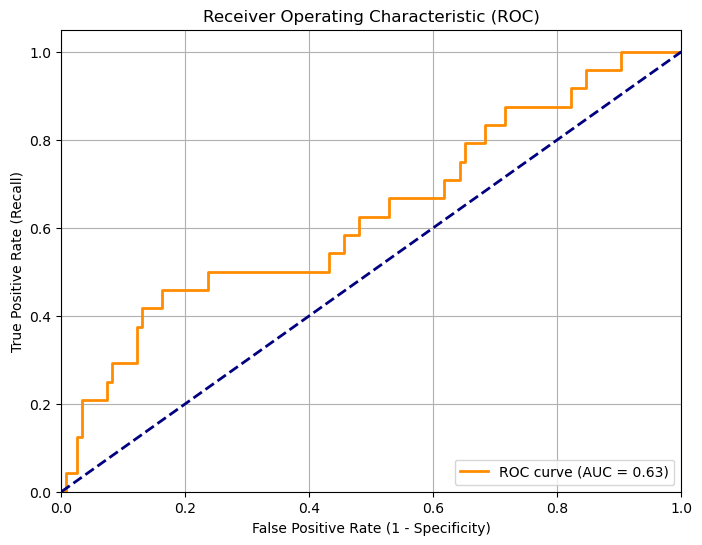

In [323]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")

plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Answer:** ROC AUV = 0.63

# Problem `T18`

Change the number of discretization bins to 5. What happens to the RoC curve? 

Which discretization is better? The number of discretization bins can be considered as a hyperparameter, and must be chosen by comparing the final performance.

In [324]:
BIN_OPTIONS = [5, 10]
LINE_COLORS = ["green", "red"]

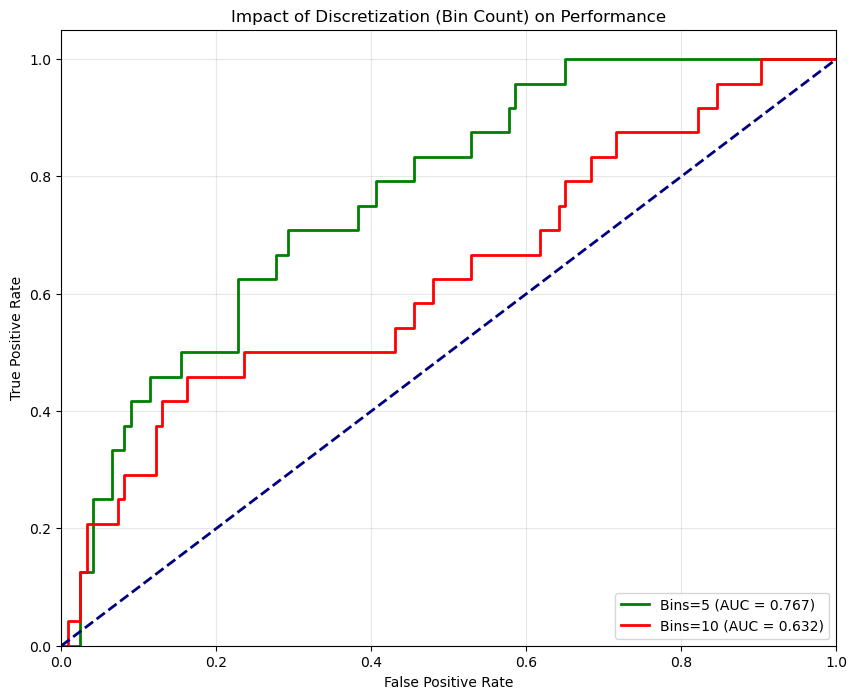

In [325]:
plt.figure(figsize=(10, 8))

for i, n_bins in enumerate(BIN_OPTIONS):
    # Train a model with different bins
    clf = SimpleBayesClassifier(n_positive, n_negative)
    clf.fit_params(X_train, y_train, n_bins=n_bins)

    # Get Scores (Log Likelihood Ratios)
    y_scores = clf.predict_scores(X_test)

    # Calculate ROC metrics
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        color=LINE_COLORS[i],
        lw=2,
        label=f"Bins={n_bins} (AUC = {roc_auc:.3f})",
    )

# Plot the diagonal line
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Impact of Discretization (Bin Count) on Performance")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

**Answer:** 5 bins is better with 0.767 ROC AUC